#  Análise Exploratória de Dados - Análise Multivariada: Goodreads Dataset

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.reshaping as rsh

---

## Carregando Dados

In [2]:
caminho = '../data/interim/books/goodreads_books_enriched.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10897, 18)


---
## Matriz de Dispersão de Valores Numéricos

Nota: Exibindo amostra aleatória de 3000 registros para performance.


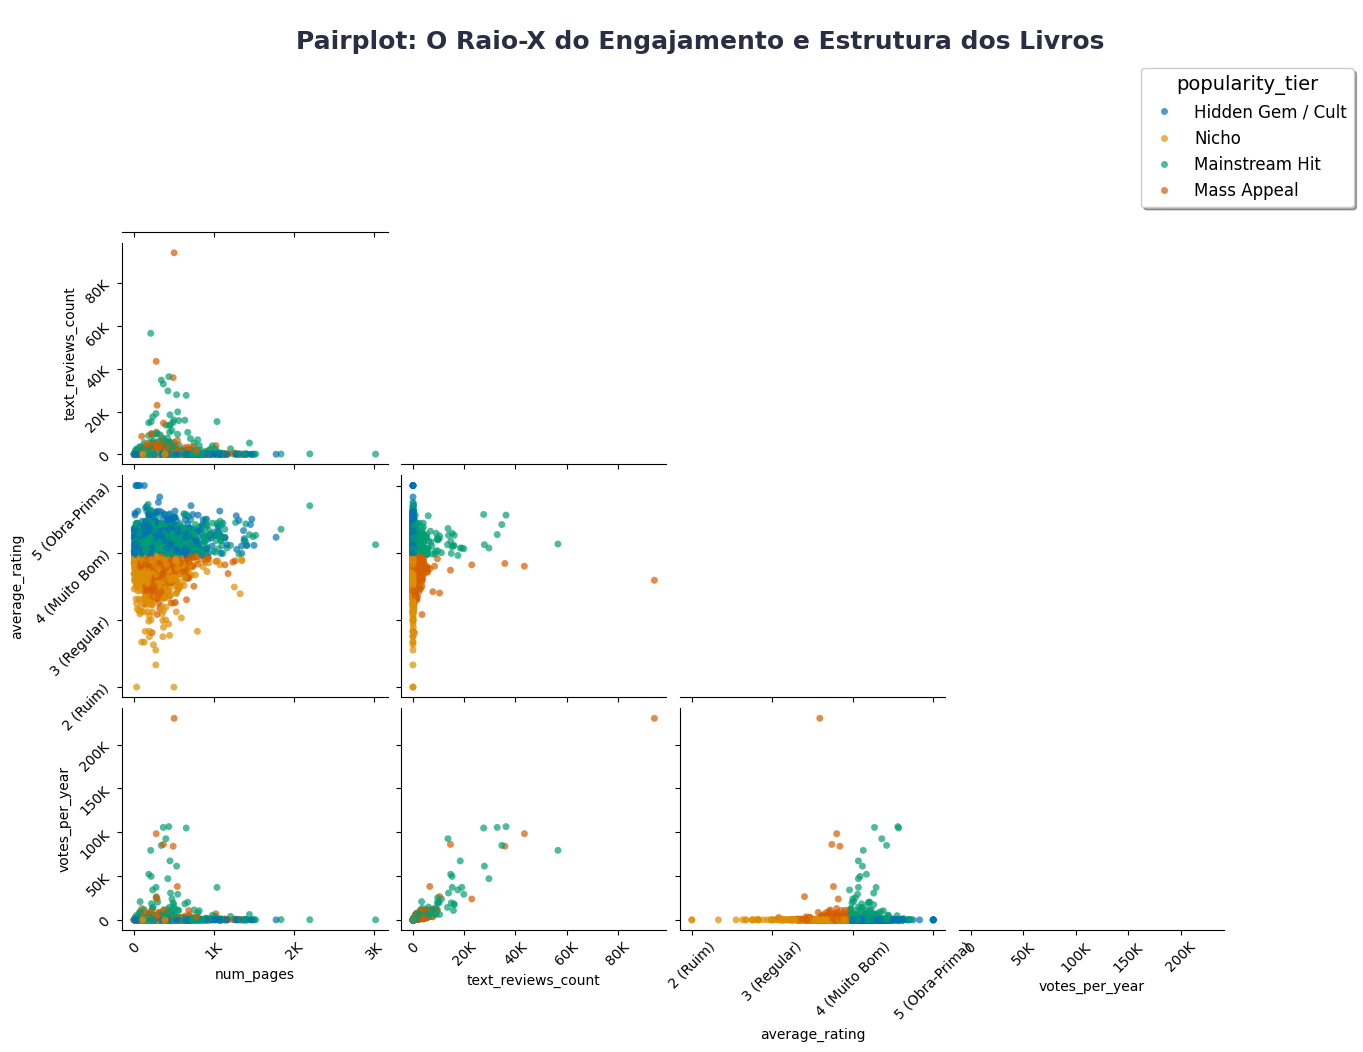

In [3]:
regras_de_escala = {
    'text_reviews_count': {'tipo_dado': 'contagem'},
    'num_pages' : {'tipo_dado': 'contagem'},
    'average_rating' : {'tipo_dado': 'nota_5'},
    'votes_per_year' : {'tipo_dado': 'contagem'}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'num_pages', 
        'text_reviews_count', 
        'average_rating', 
        'votes_per_year'
    ],
    col_log=regras_de_escala,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: O Raio-X do Engajamento e Estrutura dos Livros"
)

Nota: Exibindo amostra aleatória de 3000 registros para performance.


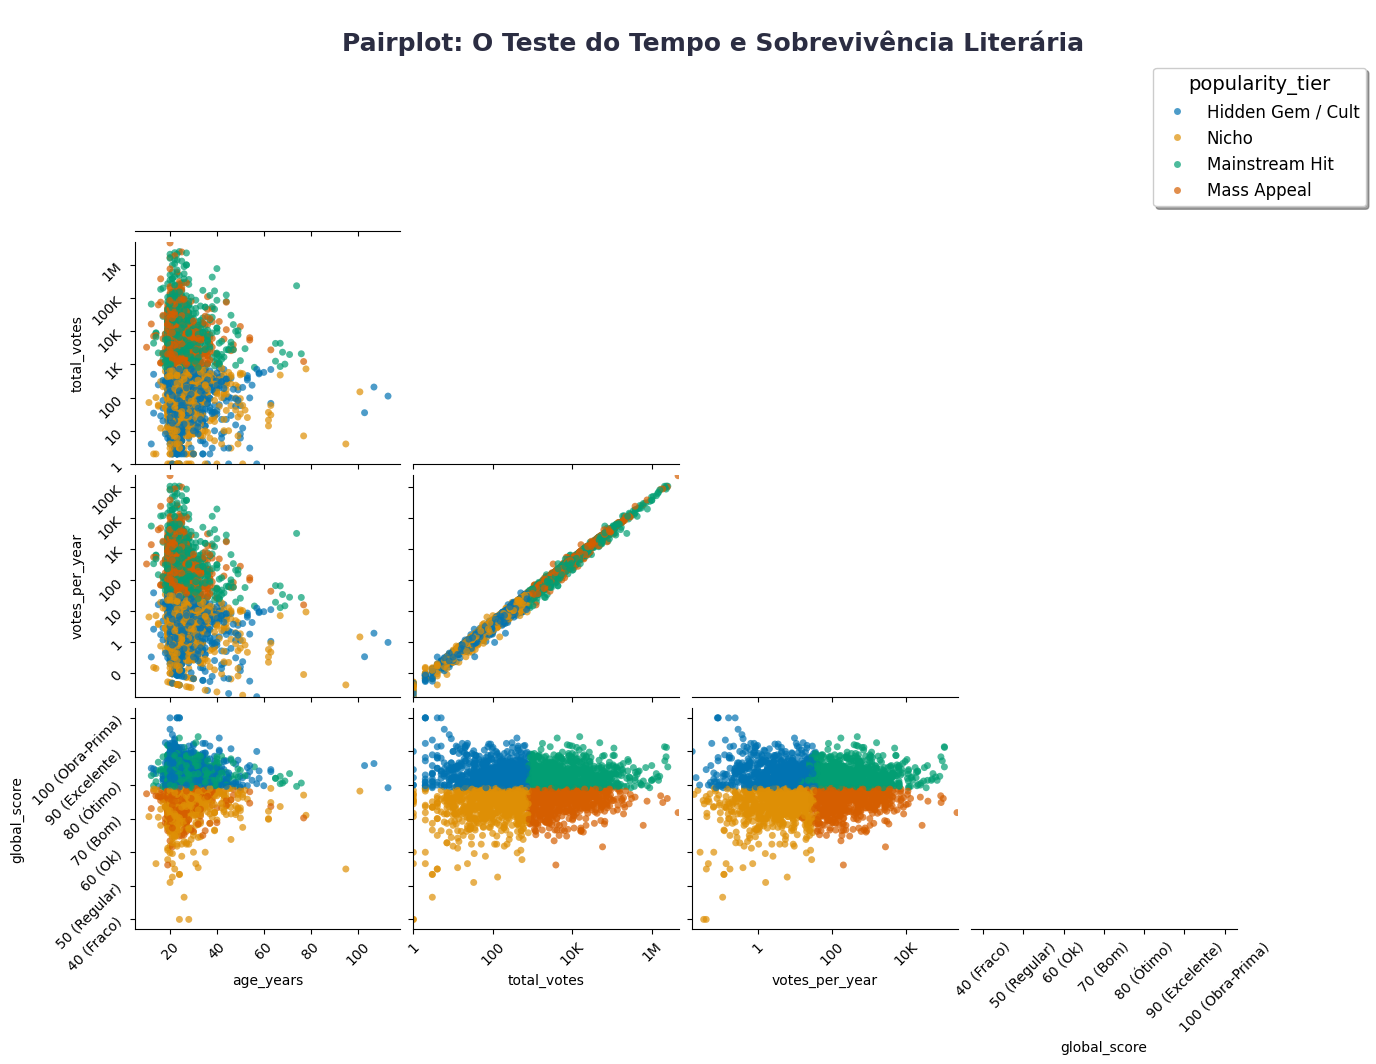

In [4]:
# Regras de escala (Votos precisam de Log para não amassar o gráfico)
regras_tempo = {
    'age_years': {'tipo_dado': 'contagem', 'usar_log': False},
    'total_votes': {'tipo_dado': 'contagem', 'usar_log': True},
    'votes_per_year': {'tipo_dado': 'contagem', 'usar_log': True},
    'global_score': {'tipo_dado': 'nota_100', 'usar_log': False}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'age_years', 
        'total_votes', 
        'votes_per_year', 
        'global_score'
    ],
    col_log=regras_tempo,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: O Teste do Tempo e Sobrevivência Literária"
)

Nota: Exibindo amostra aleatória de 3000 registros para performance.


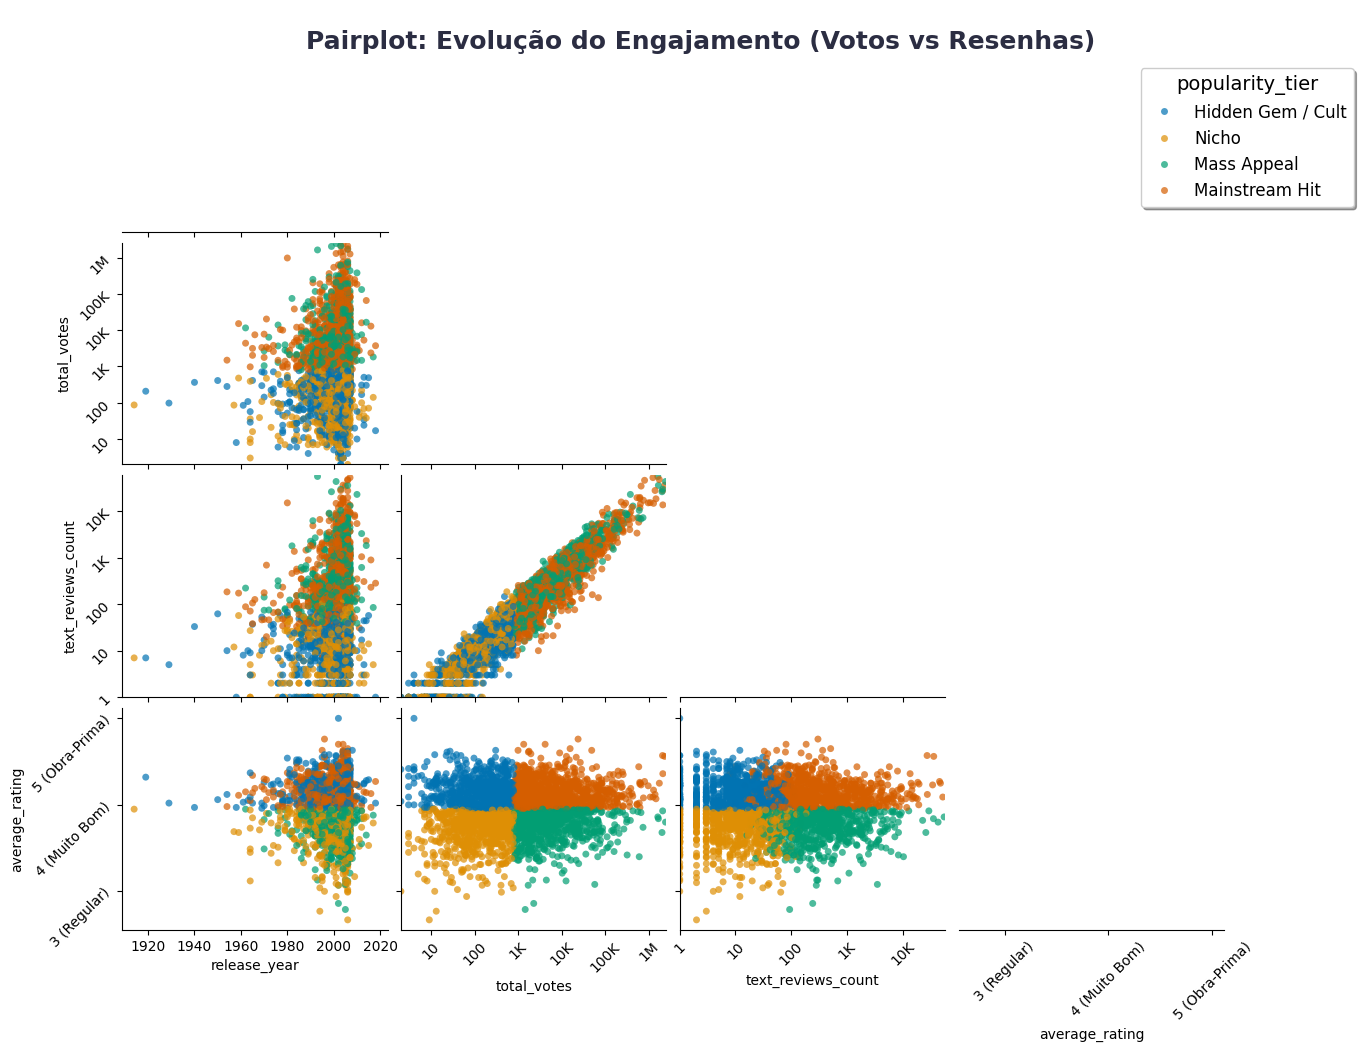

In [5]:
regras_engajamento = {
    'release_year': {'tipo_dado': None, 'usar_log': False}, 
    'total_votes': {'tipo_dado': 'contagem', 'usar_log': True},
    'text_reviews_count': {'tipo_dado': 'contagem', 'usar_log': True},
    'average_rating': {'tipo_dado': 'nota_5', 'usar_log': False}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'release_year', 
        'total_votes', 
        'text_reviews_count', 
        'average_rating'
    ],
    col_log=regras_engajamento,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: Evolução do Engajamento (Votos vs Resenhas)"
)

Nota: Exibindo amostra aleatória de 3000 registros para performance.


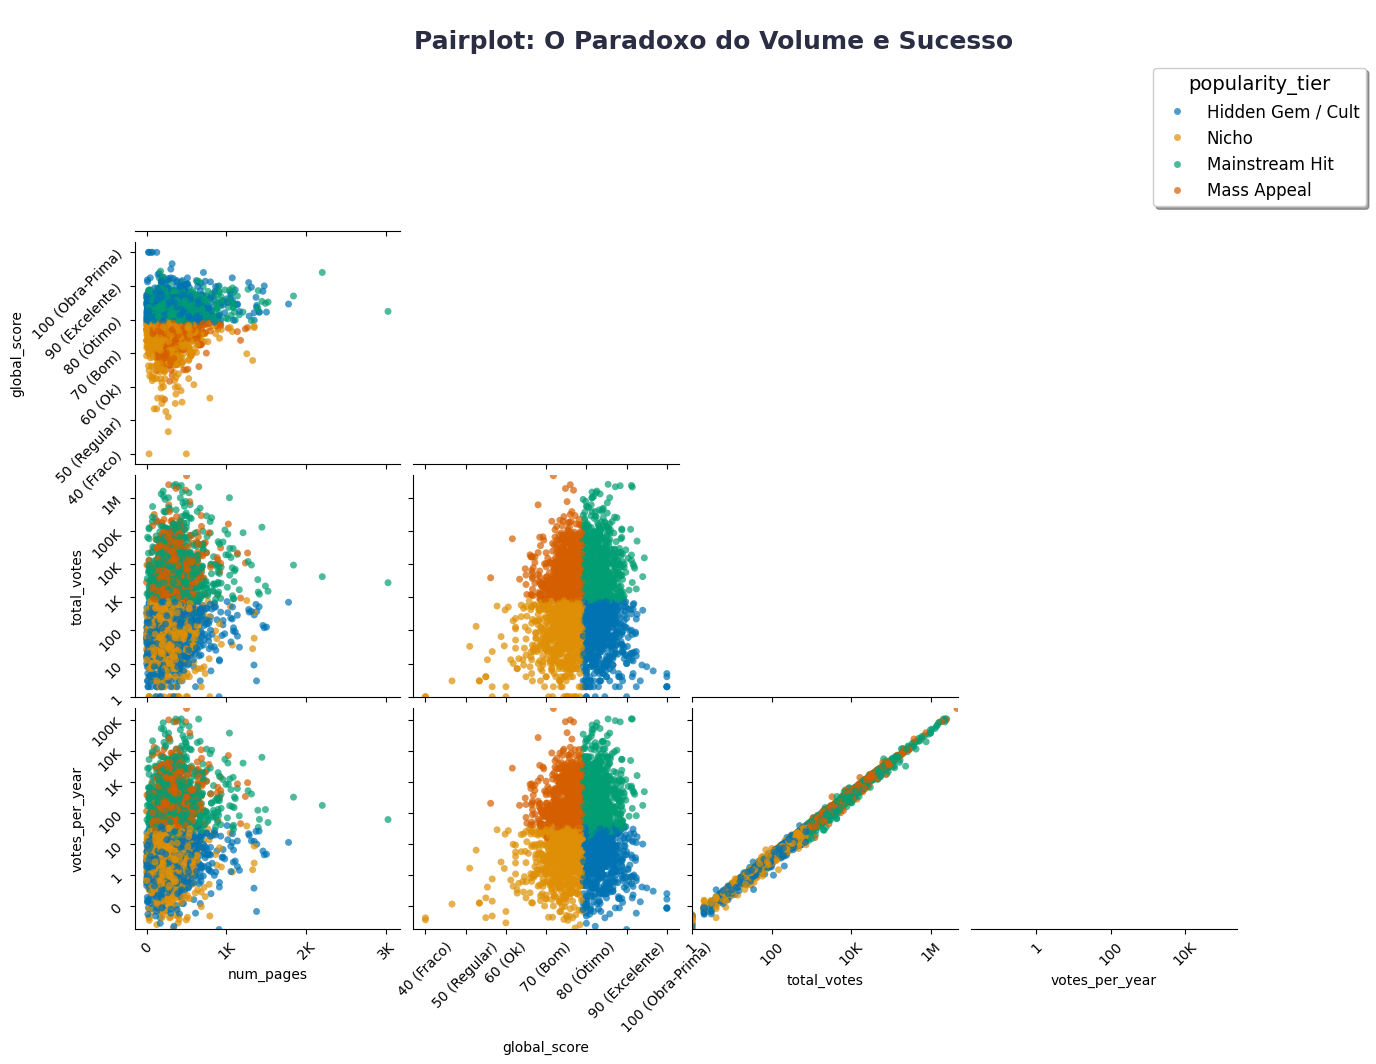

In [6]:
regras_volume = {
    'num_pages': {'tipo_dado': 'contagem', 'usar_log': False},
    'global_score': {'tipo_dado': 'nota_100', 'usar_log': False},
    'votes_per_year': {'tipo_dado': 'contagem', 'usar_log': True},
    'total_votes': {'tipo_dado': 'contagem', 'usar_log': True}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'num_pages', 
        'global_score', 
        'total_votes', 
        'votes_per_year'
    ],
    col_log=regras_volume,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: O Paradoxo do Volume e Sucesso"
)

# Conclusão Matriz de Dispersão

### Principais Conclusões:

* **A Polarização do "Mainstream":** Livros altamente populares formam uma nuvem de dispersão muito mais larga nos cruzamentos de notas (`average_rating` e `global_score`). Ao atingirem a massa, essas obras saem da sua "bolha" de fãs e sofrem penalizações severas, enquanto livros de "Nicho" ou "Cult" mantêm aglomerados densos de notas altas.
  
* **O Paradoxo do Volume (Viés do Leitor Engajado):** Diferente da intuição comum, livros muito longos (alto `num_pages`) não sofrem queda na avaliação. Os gráficos mostram que calhamaços tendem a concentrar as melhores notas médias. Isso indica um forte "viés de sobrevivência": o leitor casual abandona a obra, e apenas os fãs fiéis chegam ao final para avaliá-la.
  
* **O Esforço Literário:** A relação logarítmica entre resenhas em texto (`text_reviews_count`) e o fluxo de votos (`votes_per_year`) mostra que o engajamento literário é orgânico. Livros que sobrevivem ao teste do tempo não vivem apenas de "cliques" (votos), mas de leitores dispostos a gastar tempo escrevendo sobre eles.

**Insight Final:** A matriz prova que, no mercado editorial, **alcance nem sempre significa prestígio**. Livros que furam a bolha atraem volume de vendas, mas sacrificam sua estabilidade crítica. Além disso, o tamanho físico da obra não assusta o leitor de nicho, servindo até como um filtro para garantir avaliações mais apaixonadas.

---
## Gráfico de Bolhas

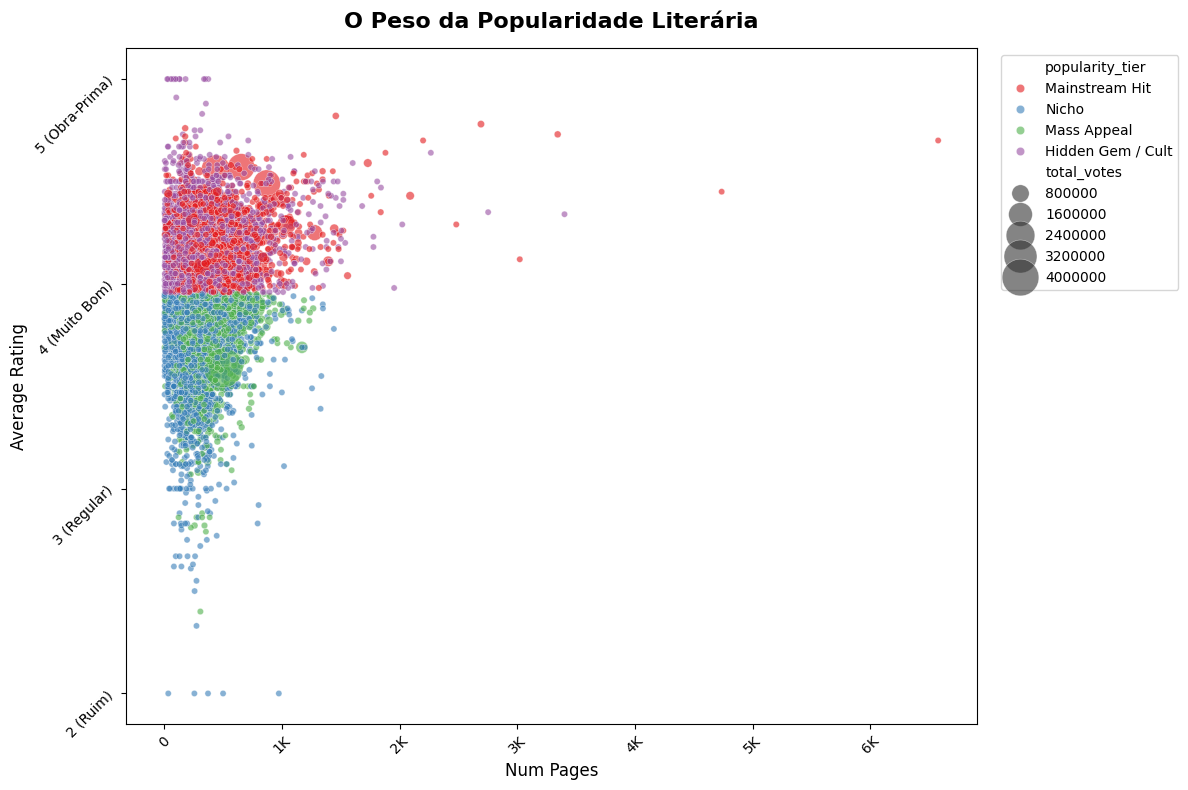

In [7]:
conf_x = {'col': 'num_pages', 'tipo_dado': 'contagem', 'usar_log': False}
conf_y = {'col': 'average_rating', 'tipo_dado': 'nota_5', 'usar_log': False}

graf.grafico_bubble_multivariado(
    df_plot=df_books,
    x_col_dict=conf_x,
    y_col_dict=conf_y,
    size_col='total_votes',
    hue_col='popularity_tier',
    titulo="O Peso da Popularidade Literária"
)

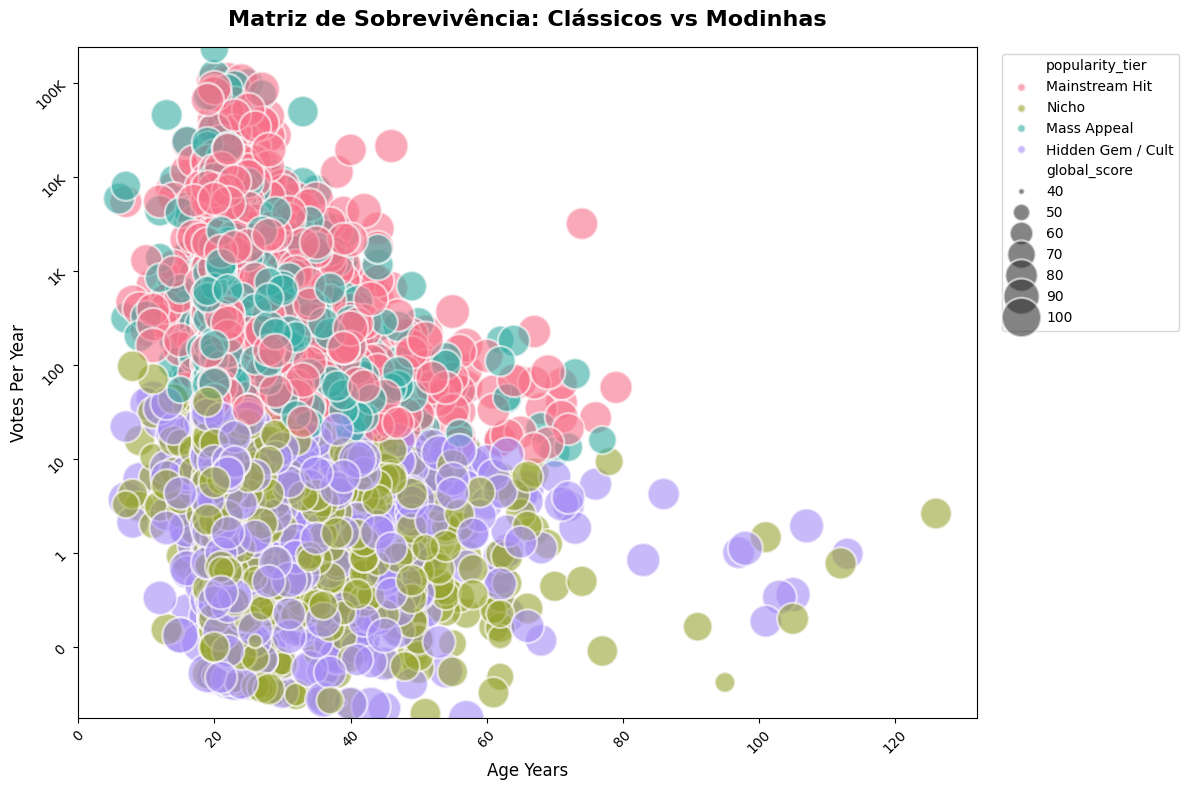

In [8]:
conf_x_idade = {'col': 'age_years', 'tipo_dado': 'contagem', 'usar_log': False}
conf_y_tracao = {'col': 'votes_per_year', 'tipo_dado': 'contagem', 'usar_log': True} 

graf.grafico_bubble_multivariado(
    df_plot=df_books,
    x_col_dict=conf_x_idade,
    y_col_dict=conf_y_tracao,
    size_col='global_score',  
    hue_col='popularity_tier',
    titulo="Matriz de Sobrevivência: Clássicos vs Modinhas",
    palette='husl'
)

# Conclusão Bubble Charts


### Principais Conclusões:

* **A Matriz de Qualidade e Estrutura (O Efeito Espelho):** O cruzamento de Páginas (X) vs Nota (Y) com Votos (Tamanho) revela uma divisão clara no mercado, funcionando como um "espelho" horizontal:
  * **O Topo (Aclamação):** Dominado pelo **Cult** e **Mainstream**. Estas obras detêm as maiores notas e variam desde livros curtos até calhamaços imensos (onde o Mainstream domina o volume de páginas). Curiosamente, à medida que o número de páginas aumenta neste grupo, as notas sofrem uma levíssima queda, mas nunca a ponto de se misturarem com a parte inferior. As verdadeiras "obras-primas" (maiores notas absolutas) pertencem ao segmento *Cult*.
  * **A Base (Diluição):** Dominada pelo **Mass Appeal** (bolhas gigantes) e **Nicho**. Concentram-se em livros mais curtos e com as piores notas gerais (os piores avaliados são do Mass Appeal). No entanto, o comportamento aqui é invertido: à medida que os livros de Mass Appeal e Nicho ganham mais páginas, as suas notas *sobem* em direção à nota 4.0, indicando que, na base, uma história mais desenvolvida ajuda a salvar a avaliação do livro.
  
* **A Matriz de Sobrevivência (Hype vs. Legado):** O segundo gráfico revela o ciclo de envelhecimento de cada categoria:
  * **Mass Appeal (O Hype Absoluto):** Atingem o ápice da tração no eixo Y, mas estão massivamente aglomerados à esquerda (obras mais recentes). São os "fenômenos pop" que explodem, mas poucos chegam aos 80 anos mantendo o mesmo fôlego.
  * **Mainstream (Os Clássicos de Ouro):** Apresentam um volume incrivelmente alto, mas com uma sobrevida muito superior ao Mass Appeal. Temos obras Mainstream sustentando alta tração mesmo com 80+ anos de idade (ex: grandes épicos e fundadores de gêneros).
  * **Cult e Nicho (A Base Estável):** Desenham uma linha horizontal consistente que ultrapassa a marca de um século de idade. Formam o catálogo de base sustentável da indústria.

**Insight Final:** O mercado editorial comporta-se em duas camadas distintas. O **Mass Appeal** é uma ferramenta de volume e faturamento com livros curtos, mas paga o preço da massificação com as piores notas. O grande tesouro comercial está no **Mainstream**, que consegue manter um volume gigantesco (bolhas enormes) e notas altas, mesmo quando as editoras arriscam publicar calhamaços. Já as obras **Cult** são o pináculo do prestígio literário: não precisam de ter volumes astronómicos de páginas ou de votos, mas são elas que garantem as "obras-primas" e a perenidade do catálogo da editora.

---
## Gráfico de Coodenadas Paralelas

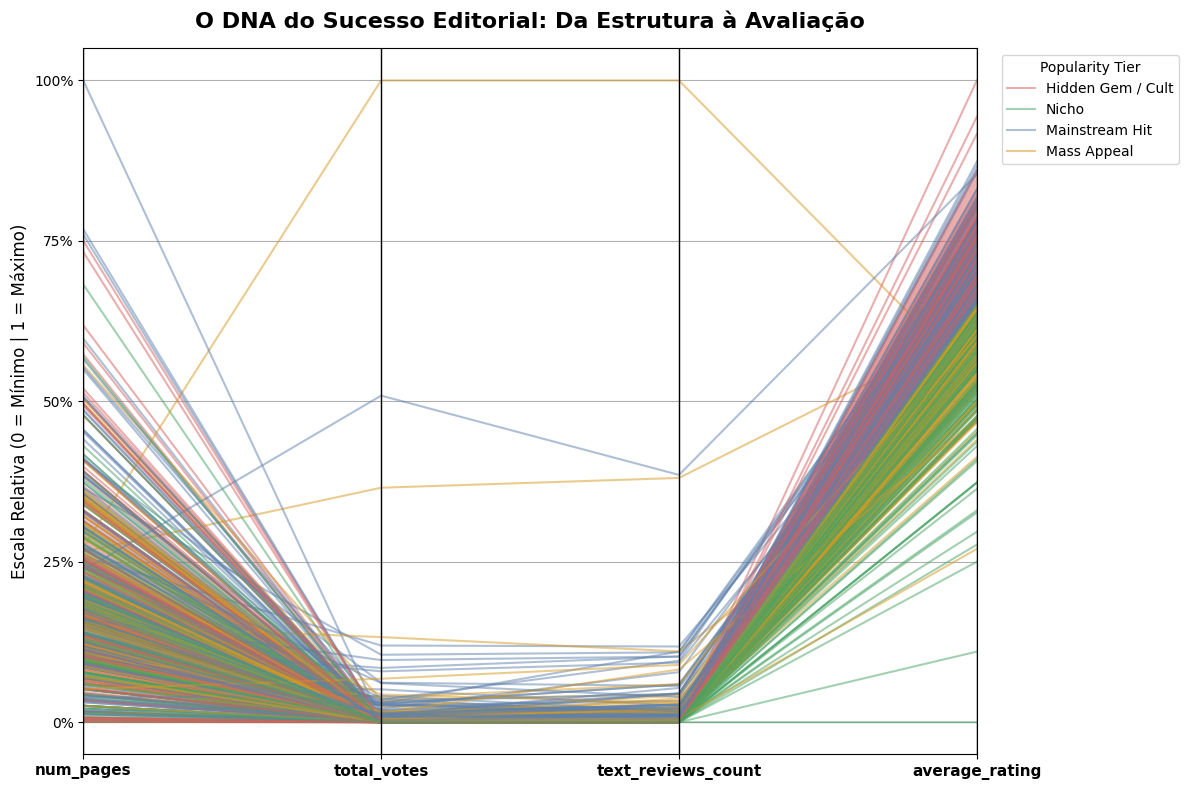

In [9]:
minha_paleta = ['#D65F5F', '#48A365', '#5E81AC', '#D79921']
graf.grafico_coordenadas_paralelas(
    df_plot=df_books,
    colunas_jornada=['num_pages', 'total_votes', 'text_reviews_count', 'average_rating'],
    coluna_categoria='popularity_tier',
    titulo="O DNA do Sucesso Editorial: Da Estrutura à Avaliação",
    palette=minha_paleta, 
    amostra=800     
)

In [15]:
graf.grafico_coordenadas_paralelas_interativo(
    df_plot=df_books,
    colunas_jornada=['num_pages', 'total_votes', 'text_reviews_count', 'average_rating'],
    coluna_categoria='popularity_tier',
    titulo='O DNA do Sucesso Editorial: Da Estrutura à Avaliação'
)

# Conclusão Gráfico de Coordenadas Paralelas

### Principais Descobertas:

* **O Trade-Off da Massificação:** O gráfico mostra que **volume e avaliação costumam ser inversamente proporcionais**.
  * O **Mass Appeal** concentra os maiores níveis de engajamento (`votes` / `reviews`), mas apresenta queda nas notas ao alcançar um público mais amplo.
  * O **Cult** e o **Mainstream** mantêm avaliações elevadas sem depender do maior volume absoluto de engajamento.

* **O Efeito Espelho na Estrutura da Obra:**
  * **Na Base (Mass Appeal/Nicho):** livros mais curtos tendem a receber avaliações piores, enquanto obras maiores costumam ser melhor avaliadas.
  * **No Topo (Cult/Mainstream):** obras muito extensas apresentam uma leve queda nas notas, sugerindo que leitores mais exigentes valorizam maior objetividade.

* **A Conversão Universal:** A relação entre votos e resenhas permanece proporcional em todas as categorias. Quem gera muitos votos também tende a gerar muitas avaliações escritas.

### Insight Final

Os dados indicam que editoras devem gerir o portfólio com estratégias distintas:

1. **O Produto Cash-Cow (Mass Appeal):** prioriza alcance, viralização e geração de receita, mesmo com possível redução das avaliações médias.

2. **O Ativo de Ouro (Mainstream):** combina alto engajamento com boas avaliações, representando o equilíbrio entre popularidade e qualidade.

3. **O Fundo de Garantia Literário (Cult/Nicho):** gera menos volume, mas fortalece o prestígio da editora e contribui para vendas consistentes ao longo do tempo.